## Ejercicio de distribución normal

(15 puntos) Suponer
que un examen tiene una calificaci´on media de 75 y una desviaci´on est´andar de 10. Asu-miendo que la distribuci´on de las calificaciones es aproximadamente normal, responder losiguiente:

* ¿Cuál es la probabilidad de que una persona escogida al azar saque una calificaciónn de 100 o mayor en este examen?
* ¿Cu´al es la calificaci´on que separa al top 2.5 % de las calificaciones?
* En un grupo de 100 personas, ¿cu´antas de ellas esperar´ıas que tuvieran una califica-
ci´on menor a 60?
* Si tomas un grupo de 100 personas y calculas su media (de muestra), ¿Cu´al es la
probabilidad de esta media de muestra resulte menor a 70? (Tip: Aqu´ı se usa una
distribuci´on muestral de la media aproximadamente normal)

In [2]:
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

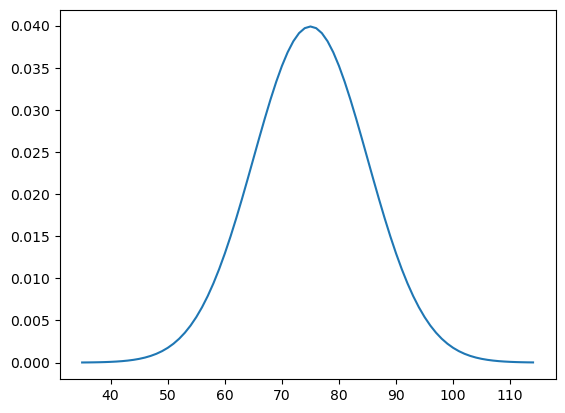

In [3]:
mu = 75
sigma = 10

# Lo graficamos a 4 desviaciones estandar de la media
# regla empirica
# 1 sigma -> 65%
# 2 sigma -> 95%
# 3 sigma -> 99.7%
# 4 sigma -> 99.9999%

x = np.arange(mu - 4*sigma,mu + 4*sigma)

plt.plot(x, st.norm.pdf(loc=mu, scale=sigma, x=x))
plt.show()

z_value =  2.5
prob(auc) =  0.62%


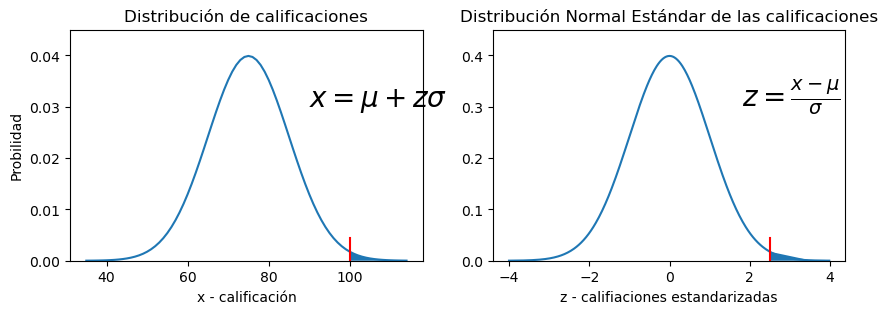

In [44]:
# inciso 1

mu = 75
sigma = 10

x = np.arange(mu - 4*sigma,mu + 4*sigma)
x_fill = np.arange(100,mu + 4*sigma)

z_eq = (100-mu) / sigma
print('z_value = ', z_eq)
auc = 1 - st.norm.cdf(loc=mu, scale=sigma, x=100)
print('prob(auc) = ', str(round(auc,4)*100) + "%")

z = np.arange(-4,4,0.02)
z_fill = np.arange(2.5,4)

fig = plt.figure(figsize=(10, 3))

ax1 = fig.add_subplot(121)
ax1.plot(x, st.norm.pdf(loc=mu, scale=sigma, x=x))
ax1.fill_between(x_fill,st.norm.pdf(loc=mu, scale=sigma, x=x_fill) )
ax1.axvline(x=100, color="red", ymin=0, ymax=0.1)
ax1.set_ylim(0,0.045)
ax1.set_title("Distribución de calificaciones")
ax1.set_xlabel("x - calificación")
ax1.set_ylabel("Probilidad")
ax1.annotate(text=r"$x = \mu + z\sigma$", xy=(90,0.03), xytext=(90,0.03), size=20)

ax2 = fig.add_subplot(122)
ax2.plot(z, st.norm.pdf(loc=0, scale=1, x=z))
ax2.fill_between(z_fill,st.norm.pdf(loc=0, scale=1, x=z_fill) )
ax2.axvline(x=z_eq, color="red", ymin=0, ymax=0.1)
ax2.set_ylim(0,0.45)
ax2.set_title("Distribución Normal Estándar de las calificaciones")
ax2.set_xlabel("z - califiaciones estandarizadas")
ax2.annotate(text=r"$z = \frac{x - \mu}{\sigma}$", xy=(1.8,0.3), xytext=(1.8,0.3), size=20)

plt.show()

#plt.plot(x, st.norm.pdf(loc=mu, scale=sigma, x=x))
#plt.title(r'$P(x>100)$')
#plt.ylabel('P(x)')
#plt.xlabel('x [calificacion]')
#plt.show()

In [45]:
# Primer inciso (rapido)
1 - st.norm.cdf(loc=mu, scale=sigma, x=100)

0.006209665325776159

In [46]:
# Primer inciso (tradicional)
# primero calculo z y luego checo tablas de z-values
#P(x>100)
mu = 75
sigma = 10
x_ref = 100

z = (x_ref - mu) / sigma
print(f'z: {z}')
print(1 - st.norm.cdf(z))

z: 2.5
0.006209665325776159


En este ejercicio, tenemos que la nota x=100 corresponde a un z-value de,

\begin{equation}
z = \frac{x - \mu}{\sigma} = \frac{100 - 75}{10} = 2.5
\end{equation}

\begin{equation}
x = z\sigma + \mu
\end{equation}

In [47]:
## Inciso 2
## Yo tengo la probabilidad 2.5% y me pide el valor de x
# (tradicional)
p = 1 - 0.025
z = st.norm.ppf(p)
print(f'z: {z}')

x_ref = z*sigma + mu
print(f'x: {x_ref}')

z: 1.959963984540054
x: 94.59963984540053


In [48]:
# Inciso 3
# de 100 personas, cuantas tendrias calificacion menor a 60
#P(x<60)


mu = 75
sigma = 10
x_ref = 60
n=100

z = (x_ref - mu) / sigma
print(f'z: {z}')
print('probabilidad de x<60',st.norm.cdf(z))
print('frecuencia de tantas personas tengan x<60 : ',n*st.norm.cdf(z))

z: -1.5
probabilidad de x<60 0.06680720126885807
frecuencia de tantas personas tengan x<60 :  6.680720126885807


z_value =  -5.0
prob(auc) =  2.8669999999999998e-05%


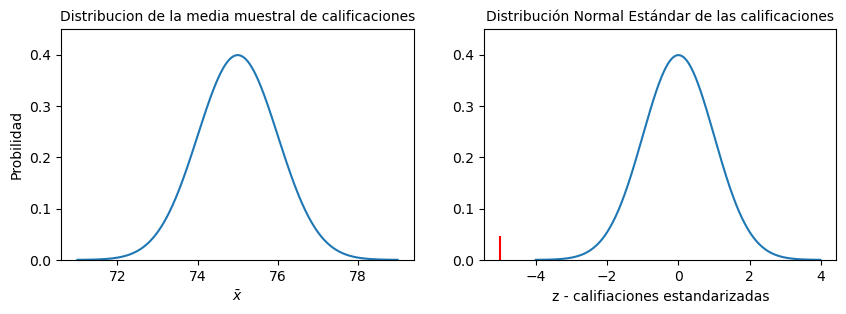

In [94]:
# inciso 4

# inciso 1

mu = 75
sigma = 10
n = 100

x = np.arange(mu-4,mu+4,0.01)
x_fill = np.arange(100,mu + 4*sigma)

z_eq = (70-mu) / (sigma/np.sqrt(n))
print('z_value = ', z_eq)
auc = st.norm.cdf(loc=mu, scale=sigma/np.sqrt(n), x=70)
print('prob(auc) = ', str(round(auc,10)*100) + "%")

z = np.arange(-4,4,0.02)
z_fill = np.arange(2.5,4)

fig = plt.figure(figsize=(10, 3))

ax1 = fig.add_subplot(121)
ax1.plot(x, st.norm.pdf(loc=mu, scale=sigma/np.sqrt(n), x=x))
#ax1.fill_between(x_fill,st.norm.pdf(loc=mu, scale=sigma, x=x_fill) )
#x1.axvline(x=100, color="red", ymin=0, ymax=0.1)
ax1.set_ylim(0,0.45)
ax1.set_title("Distribucion de la media muestral de calificaciones", size=10)
ax1.set_xlabel(r"$\bar{x}$")
ax1.set_ylabel("Probilidad")

ax2 = fig.add_subplot(122)
ax2.plot(z, st.norm.pdf(loc=0, scale=1, x=z))
#ax2.fill_between(z_fill,st.norm.pdf(loc=0, scale=1, x=z_fill) )
ax2.axvline(x=z_eq, color="red", ymin=0, ymax=0.1)
ax2.set_ylim(0,0.45)
ax2.set_title("Distribución Normal Estándar de las calificaciones", size=10)
ax2.set_xlabel("z - califiaciones estandarizadas")

plt.show()


## Teorema del límite central

Vamos a generar una distribución de edades de 8 Millones de personas (Jalisco), de manera aleatoria.

In [95]:
array_kids = np.random.normal(loc=6, scale=1.5, size=1000000)
array_teens = np.random.uniform(low=12, high=18, size=2000000)
array_adults = np.random.normal(loc=40, scale=8, size=3000000)
array_senior = np.random.exponential(scale=4.0, size=2000000)
array_senior = array_senior + 65

array_ages = np.concatenate([array_kids, array_teens, array_adults, array_senior])

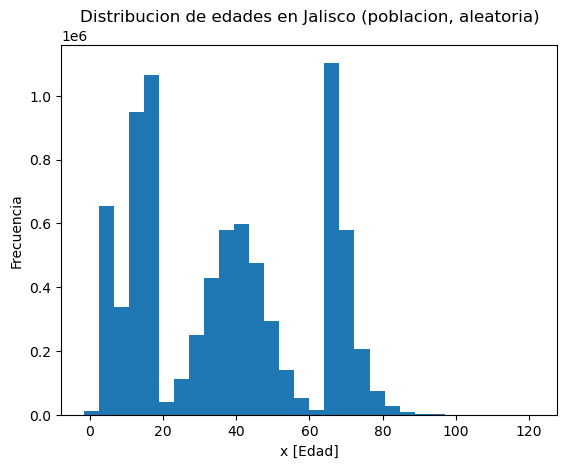

In [96]:
plt.hist(array_ages, bins=30)
plt.xlabel("x [Edad]")
plt.ylabel("Frecuencia")
plt.title("Distribucion de edades en Jalisco (poblacion, aleatoria)")
plt.show()

In [97]:
mu = np.mean(array_ages)
sigma = np.std(array_ages)
print(f'mu: {mu}')
print(f'sigma: {sigma}')

mu: 36.74854230171723
sigma: 23.00948348583418


In [98]:
## Experimento
n_sample = 90

## numero de experimentos
n_experiments = 1000

list_sample_means = []
for i in range(0,n_experiments):
    array_sample = np.random.choice(array_ages, n_sample)
    sample_mean = np.mean(array_sample)
    list_sample_means.append(sample_mean)
    #print(f'x_bar: {sample_mean}')

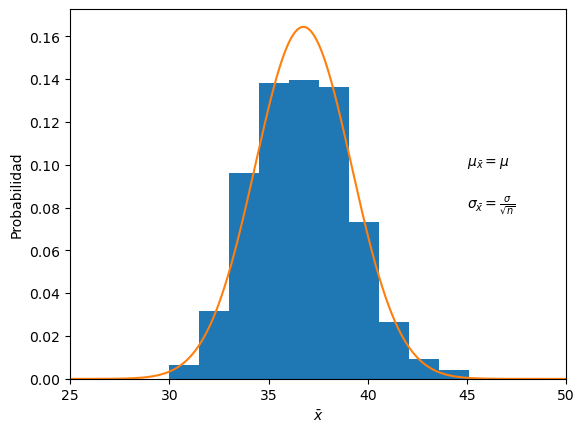

In [99]:
x = np.arange(25,50,0.01)

plt.hist(np.array(list_sample_means), density=True)
plt.plot(x, st.norm.pdf(loc=mu, scale=sigma/np.sqrt(n_sample), x=x))
plt.xlabel(r"$\bar{x}$")
plt.ylabel("Probabilidad")
plt.xlim(25,50)
plt.annotate(text=r'$\mu_{\bar{x}} = \mu $', xy = (45,0.10))
plt.annotate(text=r'$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}} $', xy = (45,0.08))
#plt.ylim(0,0.04)
plt.show()

## Teorema del límite central para proporciones

In [101]:
array_is_adult = np.where(array_ages >= 18, 1, 0) ## condition, if true, if false
array_is_adult

array([0, 0, 0, ..., 1, 1, 1])

In [117]:
p = array_is_adult.sum() / array_is_adult.shape[0] # proporcion de adultos de mi poblacion
print('prop adultos poblacion =', p)

prop adultos poblacion = 0.623874


In [128]:
## Experimento
n_sample = 100

## numero de experimentos
n_experiments = 1000

list_sample_proportions = []
for i in range(0,n_experiments):
    array_sample = np.random.choice(array_is_adult, n_sample)
    sample_mean = np.sum(array_sample) / n_sample
    list_sample_proportions.append(sample_mean)
    #print(f'p_hat: {sample_mean}')

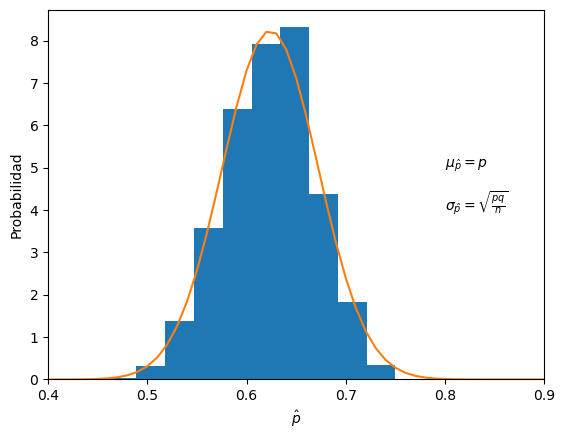

In [145]:
x = np.arange(0,1.0,0.01)

plt.hist(np.array(list_sample_proportions), density=True)
plt.plot(x, st.norm.pdf(loc=p, scale=np.sqrt(p*(1-p)/n_sample), x=x))
plt.xlabel(r"$\hat{p}$")
plt.ylabel("Probabilidad")
plt.xlim(0.4,0.9)
plt.annotate(text=r'$\mu_{\hat{p}} = p $', xy = (0.8,5))
plt.annotate(text=r'$\sigma_{\hat{p}} = \sqrt{\frac{pq}{n}} $', xy = (0.8,4))
#plt.ylim(0,0.04)
plt.show()

## Ejemplo de pandas

In [125]:
import pandas as pd

df_persons = pd.DataFrame(
    {
        "Nombre": ["Claudia", "Ivan", "Hector"],
        "Edad": [34, 36, 51]
    }
)
df_persons = df_persons.set_index(keys="Nombre")
df_persons

,Edad
Nombre,
Claudia,34
Ivan,36
Hector,51


In [126]:
df_persons.iloc[0] ## listas, arrays

Edad    34
Name: Claudia, dtype: int64

In [111]:
df_persons.loc["Claudia"] ## diccionarios

Edad    34
Name: Claudia, dtype: int64